In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

In [2]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
y_train = tf.one_hot(y_train, 10)

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

In [3]:
def train_model(hidden_size=128,
                activation='relu',
                learning_rate=0.1,
                batch_size=128,
                epochs=5):

    # Initialize weights
    W1 = tf.Variable(tf.random.normal([784, hidden_size], stddev=0.1))
    b1 = tf.Variable(tf.zeros([hidden_size]))
    W2 = tf.Variable(tf.random.normal([hidden_size, 10], stddev=0.1))
    b2 = tf.Variable(tf.zeros([10]))

    dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    dataset = dataset.shuffle(60000).batch(batch_size)

    loss_history = []
    accuracy_history = []
    weight_history = []

    for epoch in range(epochs):

        epoch_loss = 0
        correct = 0
        total = 0
        old_W1 = W1.numpy()

        for x_batch, y_batch in dataset:

            with tf.GradientTape() as tape:

                Z1 = tf.matmul(x_batch, W1) + b1

                if activation == 'relu':
                    A1 = tf.nn.relu(Z1)
                elif activation == 'sigmoid':
                    A1 = tf.nn.sigmoid(Z1)
                elif activation == 'tanh':
                    A1 = tf.nn.tanh(Z1)

                Z2 = tf.matmul(A1, W2) + b2

                loss = tf.reduce_mean(
                    tf.nn.softmax_cross_entropy_with_logits(
                        labels=y_batch,
                        logits=Z2
                    )
                )

            grads = tape.gradient(loss, [W1, b1, W2, b2])

            W1.assign_sub(learning_rate * grads[0])
            b1.assign_sub(learning_rate * grads[1])
            W2.assign_sub(learning_rate * grads[2])
            b2.assign_sub(learning_rate * grads[3])

            epoch_loss += loss.numpy()

            preds = tf.argmax(Z2, axis=1)
            labels = tf.argmax(y_batch, axis=1)

            correct += tf.reduce_sum(
                tf.cast(preds == labels, tf.float32)
            ).numpy()

            total += y_batch.shape[0]

        acc = correct / total

        loss_history.append(epoch_loss)
        accuracy_history.append(acc)

        weight_change = np.linalg.norm(W1.numpy() - old_W1)
        weight_history.append(weight_change)

    return loss_history, accuracy_history, weight_history

In [4]:
relu_loss, relu_acc, _ = train_model(activation='relu')
sig_loss, sig_acc, _ = train_model(activation='sigmoid')
tanh_loss, tanh_acc, _ = train_model(activation='tanh')

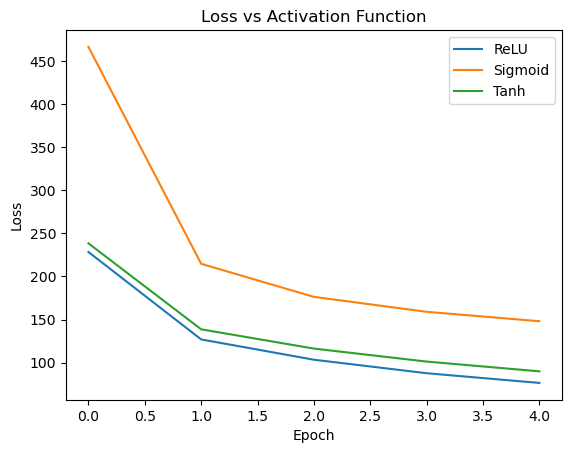

In [5]:
plt.figure()
plt.plot(relu_loss, label="ReLU")
plt.plot(sig_loss, label="Sigmoid")
plt.plot(tanh_loss, label="Tanh")
plt.legend()
plt.title("Loss vs Activation Function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

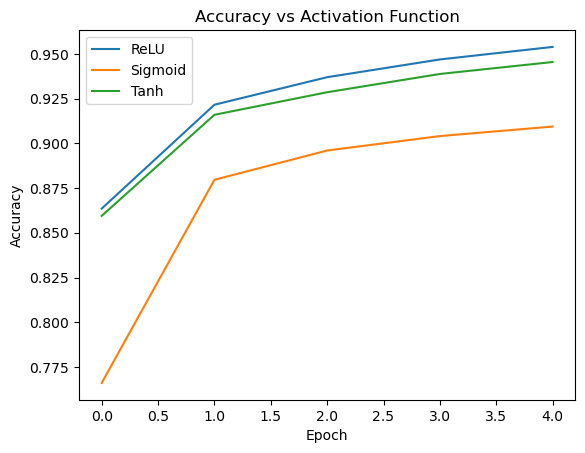

In [6]:
plt.figure()
plt.plot(relu_acc, label="ReLU")
plt.plot(sig_acc, label="Sigmoid")
plt.plot(tanh_acc, label="Tanh")
plt.legend()
plt.title("Accuracy vs Activation Function")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

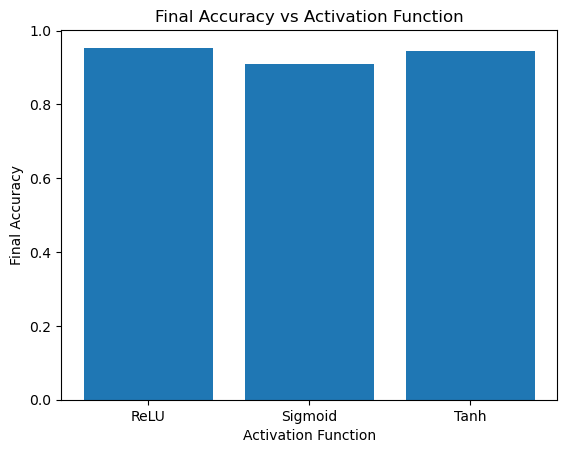

In [7]:
final_acc_activation = [
    relu_acc[-1],
    sig_acc[-1],
    tanh_acc[-1]
]

labels = ['ReLU', 'Sigmoid', 'Tanh']

plt.figure()
plt.bar(labels, final_acc_activation)
plt.title("Final Accuracy vs Activation Function")
plt.xlabel("Activation Function")
plt.ylabel("Final Accuracy")
plt.show()

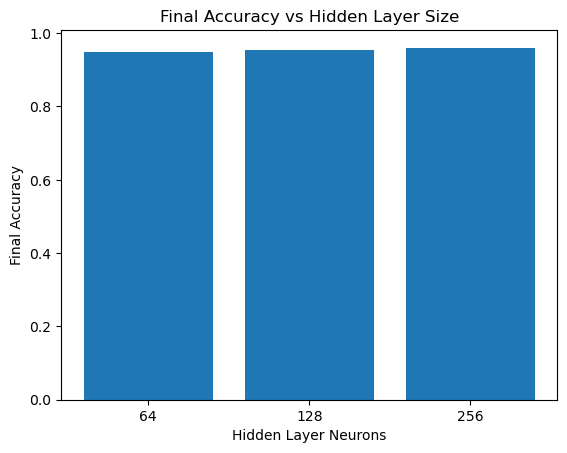

In [8]:
loss64, acc64, _ = train_model(hidden_size=64)
loss128, acc128, _ = train_model(hidden_size=128)
loss256, acc256, _ = train_model(hidden_size=256)

final_acc_hidden = [
    acc64[-1],
    acc128[-1],
    acc256[-1]
]

labels = ['64', '128', '256']

plt.figure()
plt.bar(labels, final_acc_hidden)
plt.title("Final Accuracy vs Hidden Layer Size")
plt.xlabel("Hidden Layer Neurons")
plt.ylabel("Final Accuracy")
plt.show()

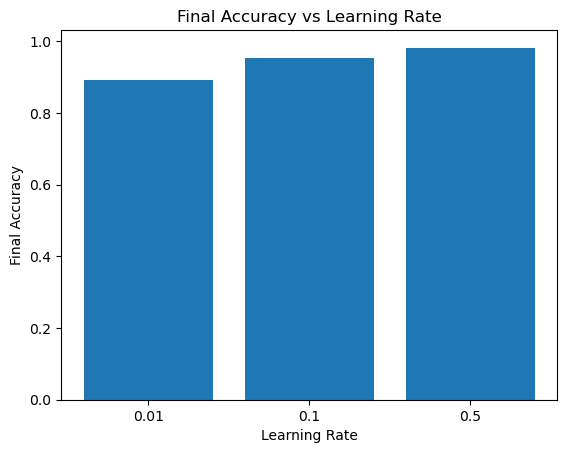

In [10]:
# Train with different learning rates
loss01, acc01, _ = train_model(learning_rate=0.01)
loss1, acc1, _ = train_model(learning_rate=0.1)
loss5, acc5, _ = train_model(learning_rate=0.5)

# Plot final accuracy comparison
final_acc_lr = [
    acc01[-1],
    acc1[-1],
    acc5[-1]
]

labels = ['0.01', '0.1', '0.5']

plt.figure()
plt.bar(labels, final_acc_lr)
plt.title("Final Accuracy vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Final Accuracy")
plt.show()

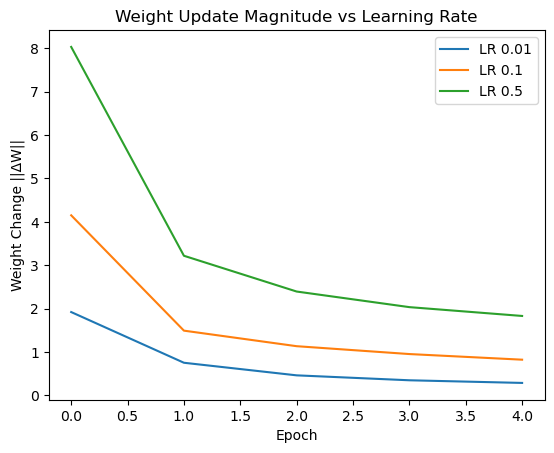

In [11]:
_, _, w01 = train_model(learning_rate=0.01)
_, _, w1 = train_model(learning_rate=0.1)
_, _, w5 = train_model(learning_rate=0.5)

plt.figure()
plt.plot(w01, label="LR 0.01")
plt.plot(w1, label="LR 0.1")
plt.plot(w5, label="LR 0.5")
plt.legend()
plt.title("Weight Update Magnitude vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Weight Change ||ΔW||")
plt.show()